<a href="https://colab.research.google.com/github/eleonoranicolai-pixel/Liquor/blob/main/Copia_di_Urine29maggio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# BLOCCO 1 — Esplorazione del dataset

import pandas as pd
import numpy as np

# Carica il file
df = pd.read_excel('ciotti 2022+emocromo+PCR.xlsx')
df.columns = [str(c).strip() for c in df.columns]

print("="*60)
print("STRUTTURA DEL FILE")
print("="*60)
print(f"Righe totali: {df.shape[0]}")
print(f"Colonne totali: {df.shape[1]}")
print(f"\nNomi colonne:")
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. {col}")

STRUTTURA DEL FILE
Righe totali: 166139
Colonne totali: 16

Nomi colonne:
    0. First Reception Date
    1. Request Label
    2. Year
    3. =Patient
    4. NTS
    5. Patient Status Description
    6. Test Description
    7. =[Result Value Final]
    8. MIC Result
    9. Unnamed: 9
   10. Risultati
   11. Coded Result Description
   12. =[Resistance Mechanism]
   13. Isolation Description
   14. Culture ID
   15. Sensibility


In [ ]:
# BLOCCO 2 — Esplorazione contenuto colonne chiave

print("="*60)
print("VALORI UNICI PER COLONNE CHIAVE")
print("="*60)

# Quanti pazienti unici
print(f"\nPazienti unici: {df['=Patient'].nunique()}")
print(f"Date uniche: {df['First Reception Date'].nunique()}")

# Tipi di test presenti
print(f"\nTipi di Test Description (primi 30):")
print(df['Test Description'].value_counts().head(30))

# Patient Status
print(f"\nPatient Status:")
print(df['Patient Status Description'].value_counts())

# Esempi di risultati
print(f"\nEsempi colonna 'Risultati' (primi 20 valori unici):")
print(df['Risultati'].dropna().unique()[:20])

# Esempi colonna Result Value Final
print(f"\nEsempi '=[Result Value Final]' (primi 20 valori unici):")
print(df['=[Result Value Final]'].dropna().unique()[:20])

VALORI UNICI PER COLONNE CHIAVE

Pazienti unici: 5797
Date uniche: 1940

Tipi di Test Description (primi 30):
Test Description
0877 - ES COLT URINA (URINOCOLT. GCOM)     9730
Globuli Bianchi                            7044
Piastrine                                  7044
RDW-CV                                     7044
Globuli Rossi                              7044
Ematocrito                                 7044
MCHC                                       7040
Volume Globulare Medio                     7040
MCH                                        7040
Emoglobina                                 7034
Neutrofili %                               7024
Linfociti %                                7024
Monociti %                                 7024
Linfociti #                                7024
Neutrofili #                               7024
Eosinofili %                               7024
Basofili %                                 7024
Eosinofili #                               7024
Basofili 

In [ ]:
# BLOCCO 3 — Costruzione matrice paziente × esami

# 1. Identificazione target (urinocoltura)
def identify_target(row):
    test = str(row['Test Description']).upper()
    res = str(row['Risultati']).strip() if pd.notnull(row['Risultati']) else ''
    if any(x in test for x in ['0877', '0878', 'URINOCOLT', 'ES COLT', 'URINA DA CATETERE']):
        if str(res) == '1':
            return 1
        if str(res) == '0':
            return 0
    return np.nan

df['target'] = df.apply(identify_target, axis=1)

# Verifica
n_pos = (df['target'] == 1).sum()
n_neg = (df['target'] == 0).sum()
print(f"Urinocolture positive trovate: {n_pos}")
print(f"Urinocolture negative trovate: {n_neg}")

# 2. Estrai target per paziente+data
target_df = df.dropna(subset=['target']).groupby(
    ['=Patient', 'First Reception Date'])['target'].max().reset_index()
print(f"\nCoppie paziente+data con urinocoltura: {len(target_df)}")
print(f"  Positive: {(target_df['target']==1).sum()}")
print(f"  Negative: {(target_df['target']==0).sum()}")

# 3. Pivot degli esami di laboratorio
# Teniamo solo le righe con valore numerico
esami_da_escludere = [
    '0877', '0878', 'URINOCOLT', 'ES COLT', 'URINA DA CATETERE',
    'MICROSCOPICO', 'Esterasi', 'PAR TEST', 'Workup',
    'CONTA MICROBICA', 'MIC Result', 'SENSIBILITY'
]

df_lab = df[~df['Test Description'].str.contains(
    '|'.join(esami_da_escludere), case=False, na=False)].copy()

# Converti valori numerici
df_lab['valore'] = pd.to_numeric(
    df_lab['=[Result Value Final]'].astype(str).str.replace(',', '.'),
    errors='coerce')

# Pivot
pivot = df_lab.pivot_table(
    index=['=Patient', 'First Reception Date'],
    columns='Test Description',
    values='valore',
    aggfunc='first'
).reset_index()

print(f"\nDimensioni pivot: {pivot.shape}")
print(f"Esami disponibili: {pivot.shape[1] - 2}")

# 4. Merge con target
final = pd.merge(pivot, target_df,
                 on=['=Patient', 'First Reception Date'],
                 how='inner')

print(f"\n{'='*50}")
print(f"DATASET FINALE")
print(f"{'='*50}")
print(f"Osservazioni totali: {len(final)}")
print(f"Positive (UTI): {(final['target']==1).sum()}")
print(f"Negative: {(final['target']==0).sum()}")
print(f"Features disponibili: {final.shape[1]-3}")

Urinocolture positive trovate: 13077
Urinocolture negative trovate: 144

Coppie paziente+data con urinocoltura: 4921
  Positive: 4807
  Negative: 114

Dimensioni pivot: (7039, 25)
Esami disponibili: 23

DATASET FINALE
Osservazioni totali: 4358
Positive (UTI): 4258
Negative: 100
Features disponibili: 23


In [ ]:
# BLOCCO 4 — Ispezione dettagliata della colonna target

# Vediamo le righe di urinocoltura con tutti i dettagli
mask_urin = df['Test Description'].str.contains(
    '0877|0878|URINOCOLT|ES COLT|URINA DA CATETERE',
    case=False, na=False)

df_urin = df[mask_urin].copy()

print(f"Righe di urinocoltura totali: {len(df_urin)}")
print(f"\nValori unici colonna 'Risultati':")
print(df_urin['Risultati'].value_counts().head(20))

print(f"\nValori unici colonna '=[Result Value Final]':")
print(df_urin['=[Result Value Final]'].value_counts().head(20))

print(f"\nValori unici colonna 'Coded Result Description':")
print(df_urin['Coded Result Description'].value_counts().head(20))

print(f"\nValori unici colonna 'Isolation Description':")
print(df_urin['Isolation Description'].value_counts().head(20))

print(f"\nPrime 10 righe di urinocoltura:")
display(df_urin[['Test Description', 'Risultati',
                  '=[Result Value Final]',
                  'Coded Result Description',
                  'Isolation Description']].head(10))

Righe di urinocoltura totali: 13221

Valori unici colonna 'Risultati':
Risultati
1    13077
0      144
Name: count, dtype: int64

Valori unici colonna '=[Result Value Final]':
=[Result Value Final]
Positiva                                                                                                                                        7426
Assenza di crescita microbica                                                                                                                   1851
Batteriuria non significativa <10^5                                                                                                             1605
VITEK_379                                                                                                                                        496
Positivo                                                                                                                                         455
ATTENZIONE: il citobatteriologico depone per scarsa prese

,Test Description,Risultati,=[Result Value Final],Coded Result Description,Isolation Description
22,0878 - URINA DA CATETERE,1,Batteriuria non significativa <10^4,BNSC,-
44,0878 - URINA DA CATETERE,1,Assenza di crescita microbica,ACB,-
55,0877 - ES COLT URINA (URINOCOLT. GCOM),0,-,-,-
78,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Assenza di crescita microbica,ACB,-
100,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Positiva,PO,Escherichia coli
101,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Positiva,PO,Escherichia coli
102,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Positiva,PO,Escherichia coli
103,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Positiva,PO,Escherichia coli
104,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Positiva,PO,Escherichia coli
105,0877 - ES COLT URINA (URINOCOLT. GCOM),1,Positiva,PO,Escherichia coli


In [ ]:
# BLOCCO 5 — Target corretto basato su Coded Result Description

def identify_target_correct(row):
    test = str(row['Test Description']).upper()
    coded = str(row['Coded Result Description']).strip().upper()
    isolation = str(row['Isolation Description']).strip()

    # Solo righe di urinocoltura
    if not any(x in test for x in ['0877', '0878', 'URINOCOLT',
                                    'ES COLT', 'URINA DA CATETERE']):
        return np.nan

    # POSITIVO — crescita batterica significativa
    if coded == 'PO':
        return 1

    # NEGATIVO — assenza di crescita o batteriuria non significativa
    if coded in ['ACB', 'ACB24', 'BNS', 'BNSC']:
        return 0

    # Tutto il resto (contaminazioni, VITEK, MT, ecc.) → escludi
    return np.nan

df['target_correct'] = df.apply(identify_target_correct, axis=1)

# Statistiche
n_pos = (df['target_correct'] == 1).sum()
n_neg = (df['target_correct'] == 0).sum()
print(f"Urinocolture POSITIVE (UTI reali): {n_pos}")
print(f"Urinocolture NEGATIVE (assenza crescita): {n_neg}")
print(f"Escluse (contaminazioni, VITEK, ecc.): "
      f"{df['Test Description'].str.contains('0877|0878', na=False).sum() - n_pos - n_neg}")

# Raggruppa per paziente+data (prendi max — se c'è almeno una positiva, è positivo)
target_df2 = df.dropna(subset=['target_correct']).groupby(
    ['=Patient', 'First Reception Date'])['target_correct'].max().reset_index()

print(f"\nCoppie paziente+data con target valido: {len(target_df2)}")
print(f"  Positive: {(target_df2['target_correct']==1).sum()}")
print(f"  Negative: {(target_df2['target_correct']==0).sum()}")
print(f"  Prevalenza UTI: "
      f"{(target_df2['target_correct']==1).sum()/len(target_df2)*100:.1f}%")

Urinocolture POSITIVE (UTI reali): 7881
Urinocolture NEGATIVE (assenza crescita): 3737
Escluse (contaminazioni, VITEK, ecc.): 1578

Coppie paziente+data con target valido: 4595
  Positive: 862
  Negative: 3733
  Prevalenza UTI: 18.8%


In [ ]:
# BLOCCO 6 — Costruzione matrice finale pulita

# 1. Esami da escludere (tutto ciò che riguarda le urine o non è emocromo/PCR)
esami_escludere = [
    '0877', '0878', 'URINOCOLT', 'ES COLT', 'URINA DA CATETERE',
    'MICROSCOPICO', 'Esterasi', 'PAR TEST', 'Workup',
    'CONTA MICROBICA', 'VITEK', 'MIC', 'Sensib',
    'CONTA', 'ANTIMICRO'
]

df_lab = df[~df['Test Description'].str.contains(
    '|'.join(esami_escludere), case=False, na=False)].copy()

print(f"Tipi di esami mantenuti:")
print(df_lab['Test Description'].value_counts())

# 2. Converti valori numerici
df_lab['valore'] = pd.to_numeric(
    df_lab['=[Result Value Final]'].astype(str).str.replace(',', '.'),
    errors='coerce')

# 3. Pivot
pivot = df_lab.pivot_table(
    index=['=Patient', 'First Reception Date'],
    columns='Test Description',
    values='valore',
    aggfunc='first'
).reset_index()

print(f"\nDimensioni pivot: {pivot.shape}")
print(f"Esami disponibili: {pivot.shape[1] - 2}")
print(f"\nNomi esami:")
for col in pivot.columns[2:]:
    print(f"  - {col}")

# 4. Estrai età dal codice fiscale
def get_age(row):
    cf = str(row['NTS']).strip()
    if len(cf) < 11:
        return np.nan
    try:
        anno_due_cifre = int(cf[6:8])
        if anno_due_cifre > 26:
            anno_nascita = 1900 + anno_due_cifre
        else:
            anno_nascita = 2000 + anno_due_cifre
        anno_test = pd.to_datetime(row['First Reception Date'], errors='coerce').year
        eta = anno_test - anno_nascita
        return eta if 0 < eta < 120 else np.nan
    except:
        return np.nan

Tipi di esami mantenuti:
Test Description
Piastrine                                  7044
Globuli Bianchi                            7044
Ematocrito                                 7044
Globuli Rossi                              7044
RDW-CV                                     7044
MCHC                                       7040
Volume Globulare Medio                     7040
MCH                                        7040
Emoglobina                                 7034
Neutrofili %                               7024
Neutrofili #                               7024
Linfociti %                                7024
Monociti %                                 7024
Linfociti #                                7024
Monociti #                                 7024
Eosinofili %                               7024
Basofili %                                 7024
Eosinofili #                               7024
Basofili #                                 7024
Eritroblasti                               641

In [ ]:
# BLOCCO 6b — Completamento merge e analisi missingness

# Rimuovi Interleuchina 6 (solo 8 osservazioni)
if 'Interleuchina 6 - Eur' in final.columns:
    final = final.drop(columns=['Interleuchina 6 - Eur'])
    print("Interleuchina 6 rimossa (8 osservazioni insufficienti)")

print(f"\n{'='*55}")
print(f"DATASET FINALE")
print(f"{'='*55}")
print(f"Osservazioni totali:  {len(final)}")
print(f"Positive (UTI):       {(final['target_correct']==1).sum()}")
print(f"Negative:             {(final['target_correct']==0).sum()}")
print(f"Features totali:      {final.shape[1]-3}")

# Missingness per feature
features = [c for c in final.columns
            if c not in ['=Patient', 'First Reception Date',
                         'target_correct', 'NTS']]

print(f"\nDati mancanti per feature:")
for f in features:
    n_miss = final[f].isna().sum()
    pct = n_miss / len(final) * 100
    flag = " ⚠️ " if pct > 30 else ""
    print(f"  {f:<45} {n_miss:>5} ({pct:>5.1f}%){flag}")

Interleuchina 6 rimossa (8 osservazioni insufficienti)

DATASET FINALE
Osservazioni totali:  4358


KeyError: 'target_correct'

In [ ]:
# BLOCCO 6c — Diagnosi problema merge

print("Tipo data in pivot:")
print(type(pivot['First Reception Date'].iloc[0]))
print(pivot['First Reception Date'].head(3))

print("\nTipo data in target_df2:")
print(type(target_df2['First Reception Date'].iloc[0]))
print(target_df2['First Reception Date'].head(3))

print("\nColonne in pivot:")
print(pivot.columns.tolist())

print("\nColonne in target_df2:")
print(target_df2.columns.tolist())

# Prova merge diagnostico
test_merge = pd.merge(pivot.head(100), target_df2,
                      on=['=Patient', 'First Reception Date'],
                      how='inner')
print(f"\nRighe nel merge diagnostico: {len(test_merge)}")

Tipo data in pivot:
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
0   2023-01-20
1   2023-02-03
2   2025-06-05
Name: First Reception Date, dtype: datetime64[ns]

Tipo data in target_df2:
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
0   2022-03-29
1   2022-05-10
2   2022-03-04
Name: First Reception Date, dtype: datetime64[ns]

Colonne in pivot:
['=Patient', 'First Reception Date', 'Basofili #', 'Basofili %', 'Ematocrito', 'Emoglobina', 'Eosinofili #', 'Eosinofili %', 'Eritroblasti', 'Globuli Bianchi', 'Globuli Rossi', 'Interleuchina 6 - Eur', 'Linfociti #', 'Linfociti %', 'MCH', 'MCHC', 'Monociti #', 'Monociti %', 'Neutrofili #', 'Neutrofili %', 'Piastrine', 'Proteina C Reattiva', 'RDW-CV', "Velocita' di Eritrosedimentazione (VES)", 'Volume Globulare Medio']

Colonne in target_df2:
['=Patient', 'First Reception Date', 'target_correct']

Righe nel merge diagnostico: 69


In [ ]:
# BLOCCO 6d — Ricostruzione dataset finale pulito

# 1. Rimuovi Interleuchina 6
if 'Interleuchina 6 - Eur' in pivot.columns:
    pivot = pivot.drop(columns=['Interleuchina 6 - Eur'])

# 2. Aggiungi età
df['First Reception Date'] = pd.to_datetime(
    df['First Reception Date'], errors='coerce')

def get_age(row):
    cf = str(row['NTS']).strip()
    if len(cf) < 11:
        return np.nan
    try:
        anno_due_cifre = int(cf[6:8])
        if anno_due_cifre > 26:
            anno_nascita = 1900 + anno_due_cifre
        else:
            anno_nascita = 2000 + anno_due_cifre
        anno_test = pd.to_datetime(
            row['First Reception Date'], errors='coerce').year
        eta = anno_test - anno_nascita
        return eta if 0 < eta < 120 else np.nan
    except:
        return np.nan

df_eta = df[['=Patient', 'First Reception Date', 'NTS']].drop_duplicates()
df_eta = df_eta.copy()
df_eta['Età'] = df_eta.apply(get_age, axis=1)
eta_map = df_eta.groupby(
    ['=Patient', 'First Reception Date'])['Età'].first().reset_index()

pivot = pd.merge(pivot, eta_map,
                 on=['=Patient', 'First Reception Date'],
                 how='left')

# 3. Calcola NLR
if 'Neutrofili #' in pivot.columns and 'Linfociti #' in pivot.columns:
    pivot['NLR'] = p

NameError: name 'p' is not defined

In [ ]:
# BLOCCO 6e — Completamento NLR e dataset finale

# Calcola NLR
if 'Neutrofili #' in pivot.columns and 'Linfociti #' in pivot.columns:
    pivot['NLR'] = pivot['Neutrofili #'] / pivot['Linfociti #']
    pivot['NLR'] = pivot['NLR'].replace([np.inf, -np.inf], np.nan)
    print("NLR calcolato")

# Merge con target
final = pd.merge(pivot, target_df2,
                 on=['=Patient', 'First Reception Date'],
                 how='inner')

print(f"\n{'='*55}")
print(f"DATASET FINALE")
print(f"{'='*55}")
print(f"Osservazioni totali:  {len(final)}")
print(f"Positive (UTI):       {(final['target_correct']==1).sum()}")
print(f"Negative:             {(final['target_correct']==0).sum()}")
print(f"Prevalenza UTI:       {(final['target_correct']==1).sum()/len(final)*100:.1f}%")
print(f"Features totali:      {final.shape[1]-3}")

features = [c for c in final.columns
            if c not in ['=Patient', 'First Reception Date', 'target_correct']]

print(f"\nDati mancanti per feature:")
for f in features:
    n_miss = final[f].isna().sum()
    pct = n_miss / len(final) * 100
    flag = " ⚠️ ALTA MISSINGNESS" if pct > 30 else ""
    print(f"  {f:<45} {n_miss:>5} ({pct:>5.1f}%){flag}")

NLR calcolato

DATASET FINALE
Osservazioni totali:  4068
Positive (UTI):       660
Negative:             3408
Prevalenza UTI:       16.2%
Features totali:      24

Dati mancanti per feature:
  Basofili #                                       32 (  0.8%)
  Basofili %                                       32 (  0.8%)
  Ematocrito                                       26 (  0.6%)
  Emoglobina                                       36 (  0.9%)
  Eosinofili #                                     32 (  0.8%)
  Eosinofili %                                     32 (  0.8%)
  Eritroblasti                                    112 (  2.8%)
  Globuli Bianchi                                  26 (  0.6%)
  Globuli Rossi                                    26 (  0.6%)
  Linfociti #                                      32 (  0.8%)
  Linfociti %                                      32 (  0.8%)
  MCH                                              26 (  0.6%)
  MCHC                                             26

In [ ]:
# BLOCCO 7 — Preparazione due dataset separati

# ── Dataset A: tutti i pazienti, solo emocromo + età + NLR ──────────────────
features_A = [
    'Basofili #', 'Basofili %', 'Ematocrito', 'Emoglobina',
    'Eosinofili #', 'Eosinofili %', 'Eritroblasti',
    'Globuli Bianchi', 'Globuli Rossi', 'Linfociti #', 'Linfociti %',
    'MCH', 'MCHC', 'Monociti #', 'Monociti %',
    'Neutrofili #', 'Neutrofili %', 'Piastrine',
    'RDW-CV', 'Volume Globulare Medio', 'Età', 'NLR'
]

# Escludi VES
df_A = final[features_A + ['target_correct']].copy()
df_A = df_A.dropna(subset=['target_correct'])

print("="*55)
print("DATASET A — Emocromo + Età + NLR (tutti i pazienti)")
print("="*55)
print(f"Osservazioni: {len(df_A)}")
print(f"Positive:     {(df_A['target_correct']==1).sum()}")
print(f"Negative:     {(df_A['target_correct']==0).sum()}")
print(f"Prevalenza:   {(df_A['target_correct']==1).sum()/len(df_A)*100:.1f}%")
print(f"Features:     {len(features_A)}")
miss_A = df_A[features_A].isna().sum()
print(f"Max missingness: {miss_A.max()} ({miss_A.max()/len(df_A)*100:.1f}%)")

# ── Dataset B: solo pazienti con PCR disponibile ─────────────────────────────
features_B = features_A + ['Proteina C Reattiva']

df_B = final[features_B + ['target_correct']].copy()
df_B = df_B.dropna(subset=['Proteina C Reattiva', 'target_correct'])

print("\n" + "="*55)
print("DATASET B — Emocromo + Età + NLR + PCR")
print("="*55)
print(f"Osservazioni: {len(df_B)}")
print(f"Positive:     {(df_B['target_correct']==1).sum()}")
print(f"Negative:     {(df_B['target_correct']==0).sum()}")
print(f"Prevalenza:   {(df_B['target_correct']==1).sum()/len(df_B)*100:.1f}%")
print(f"Features:     {len(features_B)}")

# ── Statistiche descrittive per classe ───────────────────────────────────────
print("\n" + "="*55)
print("STATISTICHE DESCRITTIVE DATASET A")
print("="*55)
desc = df_A.groupby('target_correct')[features_A].median()
print(desc.T.round(2))

DATASET A — Emocromo + Età + NLR (tutti i pazienti)
Osservazioni: 4068
Positive:     660
Negative:     3408
Prevalenza:   16.2%
Features:     22
Max missingness: 112 (2.8%)

DATASET B — Emocromo + Età + NLR + PCR
Osservazioni: 1177
Positive:     288
Negative:     889
Prevalenza:   24.5%
Features:     23

STATISTICHE DESCRITTIVE DATASET A
target_correct             0.0     1.0
Basofili #                0.03    0.03
Basofili %                0.50    0.50
Ematocrito               38.00   37.80
Emoglobina               12.60   12.40
Eosinofili #              0.11    0.11
Eosinofili %              1.50    1.60
Eritroblasti              0.00    0.00
Globuli Bianchi           7.18    7.16
Globuli Rossi             4.31    4.29
Linfociti #               1.72    1.65
Linfociti %              24.60   24.65
MCH                      30.00   29.50
MCHC                     33.40   32.90
Monociti #                0.49    0.51
Monociti %                6.90    7.20
Neutrofili #              4.60    4.

In [ ]:
# BLOCCO 8 — Split train/test CORRETTO (prima di tutto il resto)

from sklearn.model_selection import train_test_split
import numpy as np

SEED = 42
np.random.seed(SEED)

# ── DATASET A ────────────────────────────────────────────────────────────────
# Imputazione mediana SOLO sui dati di training
X_A = df_A[features_A].copy()
y_A = df_A['target_correct'].astype(int).values

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y_A, test_size=0.2, random_state=SEED, stratify=y_A)

# Imputazione con mediana calcolata SOLO sul training
from sklearn.impute import SimpleImputer
imputer_A = SimpleImputer(strategy='median')
X_A_train_imp = imputer_A.fit_transform(X_A_train)
X_A_test_imp  = imputer_A.transform(X_A_test)

print("="*55)
print("DATASET A — Split completato")
print("="*55)
print(f"Training: {X_A_train_imp.shape[0]} campioni "
      f"({y_A_train.sum()} positivi, {(y_A_train==0).sum()} negativi)")
print(f"Test:     {X_A_test_imp.shape[0]} campioni "
      f"({y_A_test.sum()} positivi, {(y_A_test==0).sum()} negativi)")
print(f"Prevalenza training: {y_A_train.mean()*100:.1f}%")
print(f"Prevalenza test:     {y_A_test.mean()*100:.1f}%")

# ── DATASET B ────────────────────────────────────────────────────────────────
X_B = df_B[features_B].copy()
y_B = df_B['target_correct'].astype(int).values

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, test_size=0.2, random_state=SEED, stratify=y_B)

imputer_B = SimpleImputer(strategy='median')
X_B_train_imp = imputer_B.fit_transform(X_B_train)
X_B_test_imp  = imputer_B.transform(X_B_test)

print("\n" + "="*55)
print("DATASET B — Split completato")
print("="*55)
print(f"Training: {X_B_train_imp.shape[0]} campioni "
      f"({y_B_train.sum()} positivi, {(y_B_train==0).sum()} negativi)")
print(f"Test:     {X_B_test_imp.shape[0]} campioni "
      f"({y_B_test.sum()} positivi, {(y_B_test==0).sum()} negativi)")
print(f"Prevalenza training: {y_B_train.mean()*100:.1f}%")
print(f"Prevalenza test:     {y_B_test.mean()*100:.1f}%")

print("\n✅ Split completato correttamente")
print("   Il test set non verrà mai toccato fino alla valutazione finale")

DATASET A — Split completato
Training: 3254 campioni (528 positivi, 2726 negativi)
Test:     814 campioni (132 positivi, 682 negativi)
Prevalenza training: 16.2%
Prevalenza test:     16.2%

DATASET B — Split completato
Training: 941 campioni (230 positivi, 711 negativi)
Test:     236 campioni (58 positivi, 178 negativi)
Prevalenza training: 24.4%
Prevalenza test:     24.6%

✅ Split completato correttamente
   Il test set non verrà mai toccato fino alla valutazione finale


In [ ]:
# BLOCCO 9 — CVAE con doppio condizionamento (label + età normalizzata)

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Iperparametri ─────────────────────────────────────────────────────────────
LATENT_DIM   = 4
HIDDEN_DIM   = 64
COND_DIM     = 2    # label + età normalizzata
BETA         = 1.0
EPOCHS       = 300
LR           = 1e-3
WEIGHT_DECAY = 1e-4

class CVAE2(nn.Module):
    """
    CVAE con doppio condizionamento: label (0/1) + età normalizzata.
    Questo garantisce che i campioni sintetici abbiano un profilo
    ematologico coerente sia con la classe che con la fascia d'età.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + COND_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU()
        )
        self.fc_mu     = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM + COND_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, input_dim)
        )

    def encode(self, x, c):
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

def cvae_loss(recon, x, mu, logvar, beta=BETA):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss

def train_cvae2(X_train, y_train, eta_train):
    """
    Addestra il CVAE con doppio condizionamento.
    X_train: features normalizzate
    y_train: label (0/1)
    eta_train: età normalizzata [0,1]
    """
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Normalizza età tra 0 e 1
    eta_norm = (eta_train - eta_train.min()) / \
               (eta_train.max() - eta_train.min() + 1e-8)

    X_tensor = torch.FloatTensor(X_scaled)
    # Condizionamento: [label, età_norm]
    c_tensor = torch.FloatTensor(
        np.column_stack([y_train, eta_norm]))

    input_dim = X_tensor.shape[1]

In [ ]:
# Verifica che CVAE2 sia definito correttamente
print("CVAE2 definito:", 'CVAE2' in dir())
print("train_cvae2 definito:", 'train_cvae2' in dir())
print("generate_synthetic2 definito:", 'generate_synthetic2' in dir())
print("LATENT_DIM:", LATENT_DIM)
print("HIDDEN_DIM:", HIDDEN_DIM)

CVAE2 definito: True
train_cvae2 definito: True
generate_synthetic2 definito: False
LATENT_DIM: 4
HIDDEN_DIM: 64


In [ ]:
# BLOCCO 9b — Funzione generazione sintetici CVAE2

def generate_synthetic2(model, scaler, n_per_class,
                        eta_pos_mean, eta_pos_std):
    """
    Genera sintetici condizionati su label E età.
    Per i positivi usa la distribuzione di età dei positivi reali.
    Per i negativi usa una distribuzione uniforme.
    """
    model.eval()
    X_syn_list = []
    y_syn_list = []

    with torch.no_grad():
        for label in [0, 1]:
            z = torch.randn(n_per_class, LATENT_DIM)

            # Età sintetica campionata dalla distribuzione reale
            if label == 1:
                eta_syn = np.random.normal(
                    eta_pos_mean, eta_pos_std, n_per_class)
            else:
                eta_syn = np.random.uniform(0, 1, n_per_class)

            eta_syn = np.clip(eta_syn, 0, 1)

            c = torch.FloatTensor(
                np.column_stack([
                    np.full(n_per_class, float(label)),
                    eta_syn
                ]))

            x_syn_scaled = model.decode(z, c).numpy()
            x_syn = scaler.inverse_transform(x_syn_scaled)
            X_syn_list.append(x_syn)
            y_syn_list.extend([label] * n_per_class)

    return np.vstack(X_syn_list), np.array(y_syn_list)

print("✅ generate_synthetic2 definita correttamente")

✅ generate_synthetic2 definita correttamente


In [ ]:
# BLOCCO 9c — Correzione train_cvae2 con return esplicito

def train_cvae2(X_train, y_train, eta_train):
    """
    Addestra il CVAE con doppio condizionamento.
    X_train: features imputate
    y_train: label (0/1)
    eta_train: età (valori reali in anni)
    """
    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Normalizza età tra 0 e 1
    eta_min = eta_train.min()
    eta_max = eta_train.max()
    eta_norm = (eta_train - eta_min) / (eta_max - eta_min + 1e-8)

    X_tensor = torch.FloatTensor(X_scaled)
    c_tensor = torch.FloatTensor(
        np.column_stack([y_train.astype(float), eta_norm]))

    input_dim = X_tensor.shape[1]
    model = CVAE2(input_dim)
    optimizer = optim.Adam(model.parameters(),
                           lr=LR, weight_decay=WEIGHT_DECAY)

    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        recon, mu, logvar = model(X_tensor, c_tensor)
        loss = cvae_loss(recon, X_tensor, mu, logvar)
        loss.backward()
        optimizer.step()

    return model, scaler, float(eta_min), float(eta_max)

print("✅ train_cvae2 corretta con return esplicito")

✅ train_cvae2 corretta con return esplicito


In [ ]:
# BLOCCO 10 — Training CVAE2 e generazione sintetici con doppio condizionamento

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Estrai colonna età dai dataset ────────────────────────────────────────────
idx_eta_A = features_A.index('Età')
idx_eta_B = features_B.index('Età')

# Età nel training set (già imputata)
eta_A_train = X_A_train_imp[:, idx_eta_A]
eta_B_train = X_B_train_imp[:, idx_eta_B]

# Statistiche età dei POSITIVI reali (per generazione sintetici)
eta_A_pos_mean = eta_A_train[y_A_train == 1].mean()
eta_A_pos_std  = eta_A_train[y_A_train == 1].std()
eta_B_pos_mean = eta_B_train[y_B_train == 1].mean()
eta_B_pos_std  = eta_B_train[y_B_train == 1].std()

print(f"Età media positivi — Dataset A: {eta_A_pos_mean:.1f} ± {eta_A_pos_std:.1f}")
print(f"Età media positivi — Dataset B: {eta_B_pos_mean:.1f} ± {eta_B_pos_std:.1f}")

# ── DATASET A ────────────────────────────────────────────────────────────────
print("\nTraining CVAE2 su Dataset A...")
torch.manual_seed(SEED)

model_A2, scaler_A2, _, _ = train_cvae2(
    X_A_train_imp, y_A_train, eta_A_train)

n_syn_A = 2726 - 528
X_syn_A2, y_syn_A2 = generate_synthetic2(
    model_A2, scaler_A2, n_syn_A,
    eta_A_pos_mean / 100,   # normalizzato
    eta_A_pos_std  / 100)

X_A_aug2 = np.vstack([X_A_train_imp, X_syn_A2])
y_A_aug2 = np.concatenate([y_A_train, y_syn_A2])

print(f"✅ Dataset A aumentato (CVAE2):")
print(f"   Totale: {len(X_A_aug2)} "
      f"({y_A_aug2.sum()} pos, {(y_A_aug2==0).sum()} neg)")

# ── DATASET B ────────────────────────────────────────────────────────────────
print("\nTraining CVAE2 su Dataset B...")
torch.manual_seed(SEED)

model_B2, scaler_B2, _, _ = train_cvae2(
    X_B_train_imp, y_B_train, eta_B_train)

n_syn_B = 711 - 230
X_syn_B2, y_syn_B2 = generate_synthetic2(
    model_B2, scaler_B2, n_syn_B,
    eta_B_pos_mean / 100,
    eta_B_pos_std  / 100)

X_B_aug2 = np.vstack([X_B_train_imp, X_syn_B2])
y_B_aug2 = np.concatenate([y_B_train, y_syn_B2])

print(f"✅ Dataset B aumentato (CVAE2):")
print(f"   Totale: {len(X_B_aug2)} "
      f"({y_B_aug2.sum()} pos, {(y_B_aug2==0).sum()} neg)")

# ── Verifica distribuzione età sintetici vs reali ─────────────────────────────
print("\n" + "="*55)
print("VERIFICA DISTRIBUZIONE ETÀ")
print("="*55)

# Età sintetici positivi Dataset A
eta_syn_pos_A = X_syn_A2[y_syn_A2 == 1, idx_eta_A]
eta_real_pos_A = eta_A_train[y_A_train == 1]

print(f"Dataset A — Positivi REALI:     "
      f"età media = {eta_real_pos_A.mean():.1f} ± {eta_real_pos_A.std():.1f}")
print(f"Dataset A — Positivi SINTETICI: "
      f"età media = {eta_syn_pos_A.mean():.1f} ± {eta_syn_pos_A.std():.1f}")

eta_syn_pos_B = X_syn_B2[y_syn_B2 == 1, idx_eta_B]
eta_real_pos_B = eta_B_train[y_B_train == 1]

print(f"Dataset B — Positivi REALI:     "
      f"età media = {eta_real_pos_B.mean():.1f} ± {eta_real_pos_B.std():.1f}")
print(f"Dataset B — Positivi SINTETICI: "
      f"età media = {eta_syn_pos_B.mean():.1f} ± {eta_syn_pos_B.std():.1f}")

print("\n✅ CVAE2 training completato")
print("   Il test set non è stato mai toccato")

Età media positivi — Dataset A: 62.4 ± 18.0
Età media positivi — Dataset B: 68.9 ± 17.3

Training CVAE2 su Dataset A...
✅ Dataset A aumentato (CVAE2):
   Totale: 7650 (2726 pos, 4924 neg)

Training CVAE2 su Dataset B...
✅ Dataset B aumentato (CVAE2):
   Totale: 1903 (711 pos, 1192 neg)

VERIFICA DISTRIBUZIONE ETÀ
Dataset A — Positivi REALI:     età media = 62.4 ± 18.0
Dataset A — Positivi SINTETICI: età media = 59.6 ± 16.5
Dataset B — Positivi REALI:     età media = 68.9 ± 17.3
Dataset B — Positivi SINTETICI: età media = 66.2 ± 15.6

✅ CVAE2 training completato
   Il test set non è stato mai toccato


In [ ]:
# BLOCCO 10b — Correzione bilanciamento dataset

# ── DATASET A ────────────────────────────────────────────────────────────────
# Tieni solo i sintetici POSITIVI (label=1)
X_syn_A2_pos = X_syn_A2[y_syn_A2 == 1]
y_syn_A2_pos = y_syn_A2[y_syn_A2 == 1]

X_A_aug2 = np.vstack([X_A_train_imp, X_syn_A2_pos])
y_A_aug2 = np.concatenate([y_A_train, y_syn_A2_pos])

print("Dataset A corretto:")
print(f"  Totale: {len(X_A_aug2)} "
      f"({y_A_aug2.sum()} pos, {(y_A_aug2==0).sum()} neg)")

# ── DATASET B ────────────────────────────────────────────────────────────────
X_syn_B2_pos = X_syn_B2[y_syn_B2 == 1]
y_syn_B2_pos = y_syn_B2[y_syn_B2 == 1]

X_B_aug2 = np.vstack([X_B_train_imp, X_syn_B2_pos])
y_B_aug2 = np.concatenate([y_B_train, y_syn_B2_pos])

print("Dataset B corretto:")
print(f"  Totale: {len(X_B_aug2)} "
      f"({y_B_aug2.sum()} pos, {(y_B_aug2==0).sum()} neg)")

# ── Verifica età sintetici positivi ──────────────────────────────────────────
eta_syn_pos_A = X_syn_A2_pos[:, idx_eta_A]
eta_real_pos_A = eta_A_train[y_A_train == 1]

print(f"\nDataset A — Positivi REALI:     "
      f"età media = {eta_real_pos_A.mean():.1f} ± "
      f"{eta_real_pos_A.std():.1f}")
print(f"Dataset A — Positivi SINTETICI: "
      f"età media = {eta_syn_pos_A.mean():.1f} ± "
      f"{eta_syn_pos_A.std():.1f}")

eta_syn_pos_B = X_syn_B2_pos[:, idx_eta_B]
eta_real_pos_B = eta_B_train[y_B_train == 1]

print(f"\nDataset B — Positivi REALI:     "
      f"età media = {eta_real_pos_B.mean():.1f} ± "
      f"{eta_real_pos_B.std():.1f}")
print(f"Dataset B — Positivi SINTETICI: "
      f"età media = {eta_syn_pos_B.mean():.1f} ± "
      f"{eta_syn_pos_B.std():.1f}")

print("\n✅ Dataset bilanciati correttamente")

Dataset A corretto:
  Totale: 5452 (2726 pos, 2726 neg)
Dataset B corretto:
  Totale: 1422 (711 pos, 711 neg)

Dataset A — Positivi REALI:     età media = 62.4 ± 18.0
Dataset A — Positivi SINTETICI: età media = 59.6 ± 16.5

Dataset B — Positivi REALI:     età media = 68.9 ± 17.3
Dataset B — Positivi SINTETICI: età media = 66.2 ± 15.6

✅ Dataset bilanciati correttamente


In [ ]:
# Aggiorna salvataggio con variabili CVAE2
import pickle
with open('/content/UTI_variables.pkl', 'wb') as f:
    pickle.dump({
        'X_A_train_imp' : X_A_train_imp,
        'X_A_test_imp'  : X_A_test_imp,
        'y_A_train'     : y_A_train,
        'y_A_test'      : y_A_test,
        'X_A_aug2'      : X_A_aug2,
        'y_A_aug2'      : y_A_aug2,
        'X_B_train_imp' : X_B_train_imp,
        'X_B_test_imp'  : X_B_test_imp,
        'y_B_train'     : y_B_train,
        'y_B_test'      : y_B_test,
        'X_B_aug2'      : X_B_aug2,
        'y_B_aug2'      : y_B_aug2,
        'features_A'    : features_A,
        'features_B'    : features_B,
        'final'         : final,
        'all_results'   : all_results,
        'df_res'        : df_res
    }, f)
print("✅ Variabili CVAE2 salvate")

✅ Variabili CVAE2 salvate


In [16]:
# BLOCCO 11 aggiornato — Training modelli con CVAE2

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_params = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

rf_params = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

lr_params = {
    'C'      : [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

results2 = {}

for dataset_name, X_aug, y_aug in [
    ('A', X_A_aug2, y_A_aug2),
    ('B', X_B_aug2, y_B_aug2)
]:
    print(f"\n{'='*55}")
    print(f"DATASET {dataset_name} — Ottimizzazione modelli (CVAE2)")
    print(f"{'='*55}")
    results2[dataset_name] = {}

    # XGBoost
    print("  XGBoost...")
    search_xgb = RandomizedSearchCV(
        XGBClassifier(random_state=SEED, eval_metric='auc',
                      verbosity=0, use_label_encoder=False),
        param_distributions=xgb_params,
        n_iter=30, scoring='roc_auc',
        cv=cv, random_state=SEED, n_jobs=-1)
    search_xgb.fit(X_aug, y_aug)
    results2[dataset_name]['XGBoost'] = {
        'model' : search_xgb.best_estimator_,
        'cv_auc': search_xgb.best_score_,
        'params': search_xgb.best_params_
    }
    print(f"  ✅ XGBoost CV AUC: {search_xgb.best_score_:.4f}")

    # Random Forest
    print("  Random Forest...")
    search_rf = RandomizedSearchCV(
        RandomForestClassifier(random_state=SEED),
        param_distributions=rf_params,
        n_iter=30, scoring='roc_auc',
        cv=cv, random_state=SEED, n_jobs=-1)
    search_rf.fit(X_aug, y_aug)
    results2[dataset_name]['RandomForest'] = {
        'model' : search_rf.best_estimator_,
        'cv_auc': search_rf.best_score_,
        'params': search_rf.best_params_
    }
    print(f"  ✅ Random Forest CV AUC: {search_rf.best_score_:.4f}")

    # Logistic Regression
    print("  Logistic Regression...")
    search_lr = RandomizedSearchCV(
        LogisticRegression(max_iter=1000, random_state=SEED),
        param_distributions=lr_params,
        n_iter=10, scoring='roc_auc',
        cv=cv, random_state=SEED, n_jobs=-1)
    search_lr.fit(X_aug, y_aug)
    results2[dataset_name]['LogisticRegression'] = {
        'model' : search_lr.best_estimator_,
        'cv_auc': search_lr.best_score_,
        'params': search_lr.best_params_
    }
    print(f"  ✅ Logistic Regression CV AUC: {search_lr.best_score_:.4f}")

print("\n✅ Ottimizzazione completata con CVAE2")


DATASET A — Ottimizzazione modelli (CVAE2)
  XGBoost...
  ✅ XGBoost CV AUC: 0.9445
  Random Forest...
  ✅ Random Forest CV AUC: 0.9445
  Logistic Regression...
  ✅ Logistic Regression CV AUC: 0.8467

DATASET B — Ottimizzazione modelli (CVAE2)
  XGBoost...
  ✅ XGBoost CV AUC: 0.8901
  Random Forest...
  ✅ Random Forest CV AUC: 0.8874
  Logistic Regression...
  ✅ Logistic Regression CV AUC: 0.7399

✅ Ottimizzazione completata con CVAE2


In [17]:
# BLOCCO SALVATAGGIO — Salva variabili localmente nella sessione
import pickle
with open('/content/UTI_variables.pkl', 'wb') as f:
    pickle.dump({
        'X_A_train_imp': X_A_train_imp,
        'X_A_test_imp' : X_A_test_imp,
        'y_A_train'    : y_A_train,
        'y_A_test'     : y_A_test,
        'X_A_aug'      : X_A_aug,
        'y_A_aug'      : y_A_aug,
        'X_B_train_imp': X_B_train_imp,
        'X_B_test_imp' : X_B_test_imp,
        'y_B_train'    : y_B_train,
        'y_B_test'     : y_B_test,
        'X_B_aug'      : X_B_aug,
        'y_B_aug'      : y_B_aug,
        'features_A'   : features_A,
        'features_B'   : features_B,
        'results'      : results
    }, f)
print("✅ Variabili salvate localmente")

NameError: name 'X_A_aug' is not defined

In [ ]:
# BLOCCO 11b — Diagnosi overfitting e importanza features

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── 1. Feature importance XGBoost Dataset A ──────────────────────────────────
model_xgb_A = results['A']['XGBoost']['model']
imp_A = pd.DataFrame({
    'Feature'   : features_A,
    'Importance': model_xgb_A.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*55)
print("TOP 10 FEATURE IMPORTANCE — XGBoost Dataset A")
print("="*55)
print(imp_A.head(10).to_string(index=False))

# ── 2. Verifica: AUC sui soli dati REALI del training ────────────────────────
# Se il modello funziona bene solo sui reali, è genuino
# Se funziona bene solo sui sintetici, c'è un problema

from sklearn.metrics import roc_auc_score

# Predizioni sui soli campioni reali del training
probs_real_A = model_xgb_A.predict_proba(X_A_train_imp)[:, 1]
auc_real_A   = roc_auc_score(y_A_train, probs_real_A)

print(f"\nAUC sui dati REALI di training (A): {auc_real_A:.4f}")
print(f"AUC CV sul dataset aumentato (A):   "
      f"{results['A']['XGBoost']['cv_auc']:.4f}")

if auc_real_A > 0.95:
    print("⚠️  AUC molto alto sui reali — l'età potrebbe dominare")
else:
    print("✅  AUC più basso sui reali — il modello non overfitting sui sintetici")

# ── 3. Test estremo: modello con SOLO età ────────────────────────────────────
from xgboost import XGBClassifier

idx_eta = features_A.index('Età')
X_eta_only = X_A_train_imp[:, [idx_eta]]
X_eta_test = X_A_test_imp[:, [idx_eta]]

xgb_eta = XGBClassifier(n_estimators=100, random_state=SEED,
                         eval_metric='auc', verbosity=0)
xgb_eta.fit(X_A_aug[:, [idx_eta]],  y_A_aug)
auc_eta_test = roc_auc_score(
    y_A_test,
    xgb_eta.predict_proba(X_eta_test)[:, 1])

print(f"\nAUC con SOLO età sul test set: {auc_eta_test:.4f}")
print("(Se è vicino a 0.94, l'età spiega quasi tutto)")

# ── 4. Test: modello SENZA età ───────────────────────────────────────────────
features_no_eta = [f for f in features_A if f != 'Età']
idx_no_eta = [features_A.index(f) for f in features_no_eta]

xgb_no_eta = XGBClassifier(n_estimators=100, random_state=SEED,
                             eval_metric='auc', verbosity=0)
xgb_no_eta.fit(X_A_aug[:, idx_no_eta], y_A_aug)
auc_no_eta_test = roc_auc_score(
    y_A_test,
    xgb_no_eta.predict_proba(X_A_test_imp[:, idx_no_eta])[:, 1])

print(f"AUC SENZA età sul test set:    {auc_no_eta_test:.4f}")
print("(Questo è il contributo puro dell'emocromo)")

TOP 10 FEATURE IMPORTANCE — XGBoost Dataset A
      Feature  Importance
 Eritroblasti    0.471319
       RDW-CV    0.227992
   Basofili %    0.107939
          Età    0.037460
   Emoglobina    0.034816
  Linfociti %    0.018215
Globuli Rossi    0.014398
   Ematocrito    0.011094
    Piastrine    0.007879
 Neutrofili %    0.007855

AUC sui dati REALI di training (A): 0.7752
AUC CV sul dataset aumentato (A):   0.9454
✅  AUC più basso sui reali — il modello non overfitting sui sintetici

AUC con SOLO età sul test set: 0.6441
(Se è vicino a 0.94, l'età spiega quasi tutto)
AUC SENZA età sul test set:    0.5879
(Questo è il contributo puro dell'emocromo)


PERFORMANCE SUL TEST SET — RISULTATI FINALI


'Dataset            Modello  AUC-ROC  AP (PR-AUC)  Sensitivity  Specificity    PPV    NPV  Accuracy\n      A            XGBoost   0.6668       0.2743       0.0076       0.9883 0.1111 0.8373    0.8292\n      A       RandomForest   0.6677       0.2754       0.0076       0.9971 0.3333 0.8385    0.8366\n      A LogisticRegression   0.6643       0.2934       0.5000       0.7610 0.2882 0.8872    0.7187\n      B            XGBoost   0.6187       0.3523       0.1379       0.9494 0.4706 0.7717    0.7500\n      B       RandomForest   0.6106       0.3519       0.0517       0.9775 0.4286 0.7598    0.7500\n      B LogisticRegression   0.6767       0.4131       0.6379       0.6910 0.4022 0.8542    0.6780'

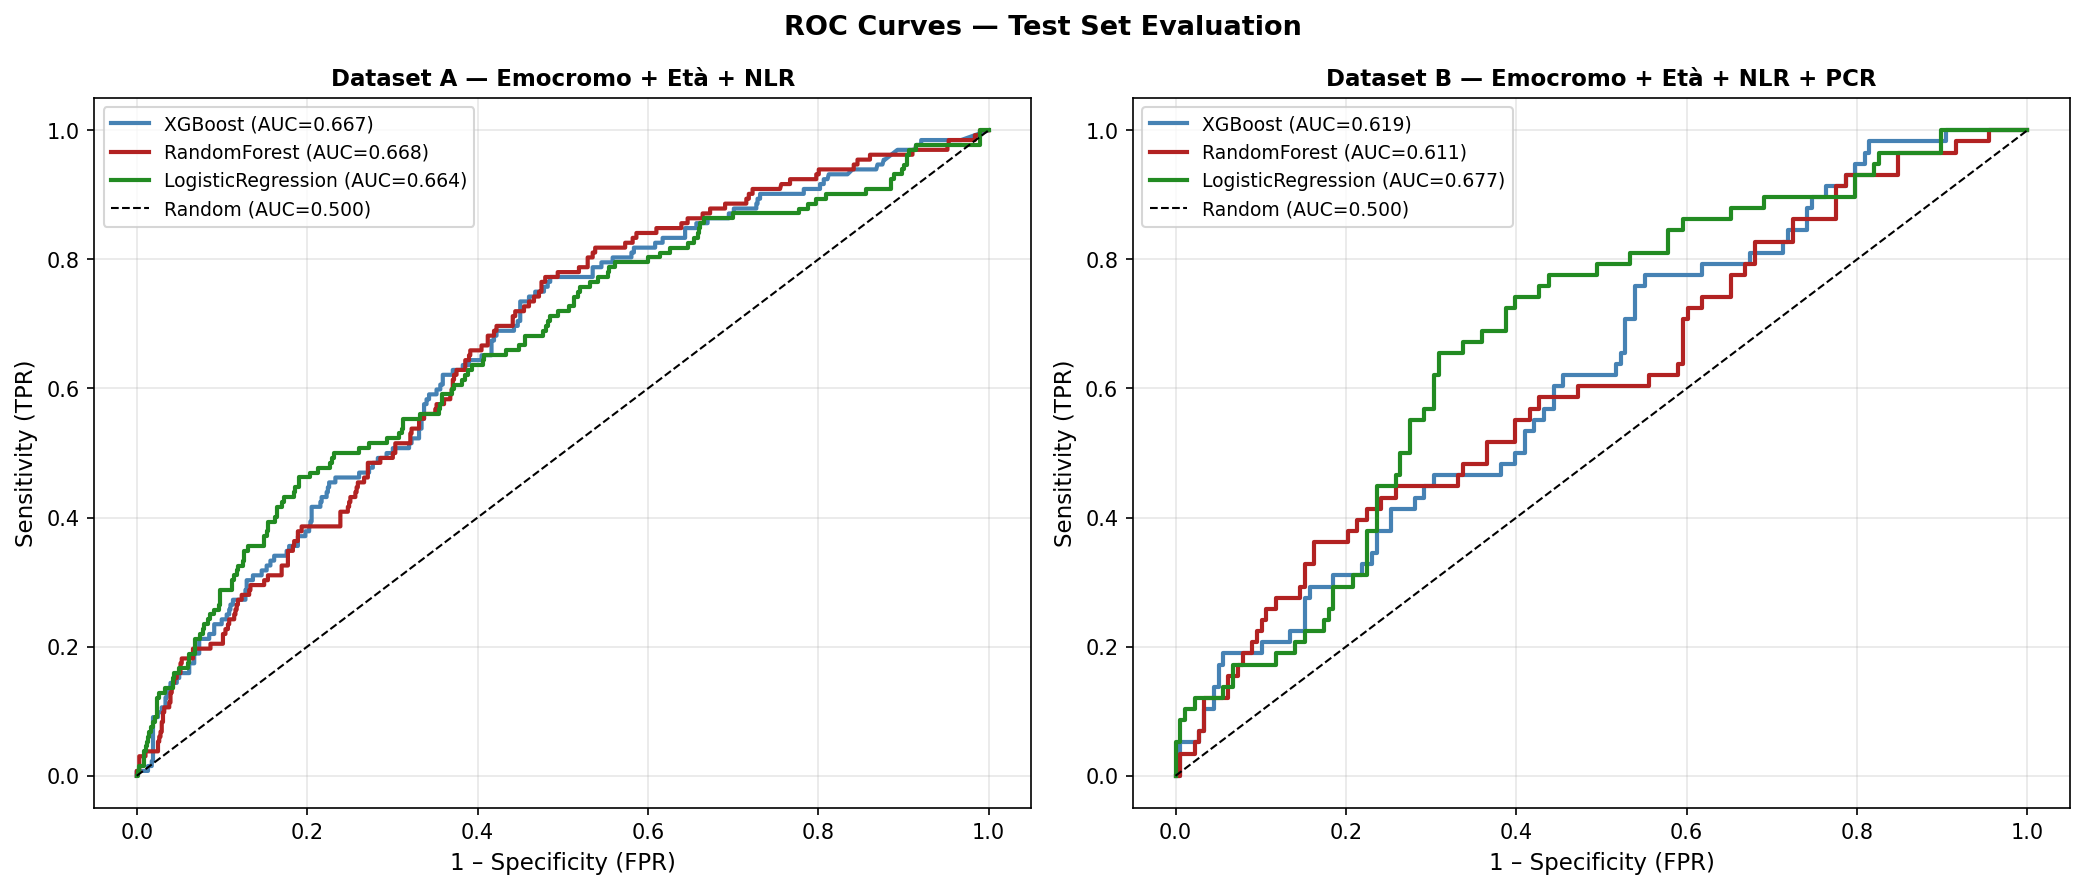

✅ Figura salvata: ROC_curves_UTI.png


In [ ]:
# BLOCCO 12 — Valutazione finale sul test set

from sklearn.metrics import (roc_auc_score, roc_curve, auc,
                              confusion_matrix, classification_report,
                              precision_recall_curve,
                              average_precision_score)
import matplotlib.pyplot as plt
import numpy as np

SEED = 42

# ── Funzione di valutazione completa ─────────────────────────────────────────
def evaluate_model(name, model, X_test, y_test, features, dataset_name):
    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)

    auc_roc = roc_auc_score(y_test, probs)
    ap      = average_precision_score(y_test, probs)
    cm      = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy    = (tp + tn) / len(y_test)

    return {
        'Dataset'    : dataset_name,
        'Modello'    : name,
        'AUC-ROC'    : round(auc_roc, 4),
        'AP (PR-AUC)': round(ap, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'PPV'        : round(ppv, 4),
        'NPV'        : round(npv, 4),
        'Accuracy'   : round(accuracy, 4),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'probs'      : probs,
        'y_test'     : y_test
    }

# ── Valutazione tutti i modelli ───────────────────────────────────────────────
all_results = []

for dataset_name, X_test, y_test, features in [
    ('A', X_A_test_imp, y_A_test, features_A),
    ('B', X_B_test_imp, y_B_test, features_B)
]:
    for model_name in ['XGBoost', 'RandomForest', 'LogisticRegression']:
        model = results[dataset_name][model_name]['model']
        res   = evaluate_model(model_name, model,
                               X_test, y_test,
                               features, dataset_name)
        all_results.append(res)

# ── Tabella riassuntiva ───────────────────────────────────────────────────────
df_res = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ['probs', 'y_test']}
                       for r in all_results])

print("="*70)
print("PERFORMANCE SUL TEST SET — RISULTATI FINALI")
print("="*70)
display(df_res[['Dataset', 'Modello', 'AUC-ROC', 'AP (PR-AUC)',
                'Sensitivity', 'Specificity', 'PPV', 'NPV',
                'Accuracy']].to_string(index=False))

# ── Curva ROC per tutti i modelli ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
colors = {'XGBoost': 'steelblue',
          'RandomForest': 'firebrick',
          'LogisticRegression': 'forestgreen'}

for ax, dataset_name, title in [
    (axes[0], 'A', 'Dataset A — Emocromo + Età + NLR'),
    (axes[1], 'B', 'Dataset B — Emocromo + Età + NLR + PCR')
]:
    for r in all_results:
        if r['Dataset'] != dataset_name:
            continue
        fpr, tpr, _ = roc_curve(r['y_test'], r['probs'])
        ax.plot(fpr, tpr,
                color=colors[r['Modello']], lw=2,
                label=f"{r['Modello']} (AUC={r['AUC-ROC']:.3f})")

    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.500)')
    ax.set_xlabel('1 – Specificity (FPR)', fontsize=11)
    ax.set_ylabel('Sensitivity (TPR)', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ROC_curves_UTI.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura salvata: ROC_curves_UTI.png")

In [ ]:
# BLOCCO SALVATAGGIO
import pickle
with open('/content/UTI_variables.pkl', 'wb') as f:
    pickle.dump({
        'X_A_train_imp' : X_A_train_imp,
        'X_A_test_imp'  : X_A_test_imp,
        'y_A_train'     : y_A_train,
        'y_A_test'      : y_A_test,
        'X_A_aug'       : X_A_aug,
        'y_A_aug'       : y_A_aug,
        'X_B_train_imp' : X_B_train_imp,
        'X_B_test_imp'  : X_B_test_imp,
        'y_B_train'     : y_B_train,
        'y_B_test'      : y_B_test,
        'X_B_aug'       : X_B_aug,
        'y_B_aug'       : y_B_aug,
        'features_A'    : features_A,
        'features_B'    : features_B,
        'results'       : results,
        'all_results'   : all_results,
        'df_res'        : df_res,
        'final'         : final
    }, f)
print("✅ Variabili salvate")

✅ Variabili salvate


In [ ]:
# BLOCCO CARICAMENTO — Ripristina tutte le variabili salvate

import pickle
import pandas as pd
import numpy as np
import torch

with open('/content/UTI_variables.pkl', 'rb') as f:
    data = pickle.load(f)

# Ripristina tutte le variabili
X_A_train_imp = data['X_A_train_imp']
X_A_test_imp  = data['X_A_test_imp']
y_A_train     = data['y_A_train']
y_A_test      = data['y_A_test']
X_A_aug2      = data['X_A_aug2']
y_A_aug2      = data['y_A_aug2']
X_B_train_imp = data['X_B_train_imp']
X_B_test_imp  = data['X_B_test_imp']
y_B_train     = data['y_B_train']
y_B_test      = data['y_B_test']
X_B_aug2      = data['X_B_aug2']
y_B_aug2      = data['y_B_aug2']
features_A    = data['features_A']
features_B    = data['features_B']
final         = data['final']
results2      = data['results2']
all_results   = data['all_results']
all_results2  = data['all_results2']
df_res        = data['df_res']
df_res2       = data['df_res2']
df_boot       = data['df_boot']
shap_values   = data['shap_values']
shap_geri     = data['shap_geri']
shap_nongeri  = data['shap_nongeri']
geri_idx      = data['geri_idx']
nongeri_idx   = data['nongeri_idx']
pos_geri      = data['pos_geri']
pos_nongeri   = data['pos_nongeri']

SEED = 42

print("✅ Tutte le variabili caricate correttamente")
print(f"   Dataset A: {X_A_test_imp.shape[0]} campioni test")
print(f"   Dataset B: {X_B_test_imp.shape[0]} campioni test")
print(f"   Features A: {len(features_A)}")
print(f"   Features B: {len(features_B)}")
print(f"   Modelli disponibili: {list(results2['A'].keys())}")

✅ Tutte le variabili caricate correttamente
   Dataset A: 814 campioni test
   Dataset B: 236 campioni test
   Features A: 22
   Features B: 23
   Modelli disponibili: ['XGBoost', 'RandomForest', 'LogisticRegression']


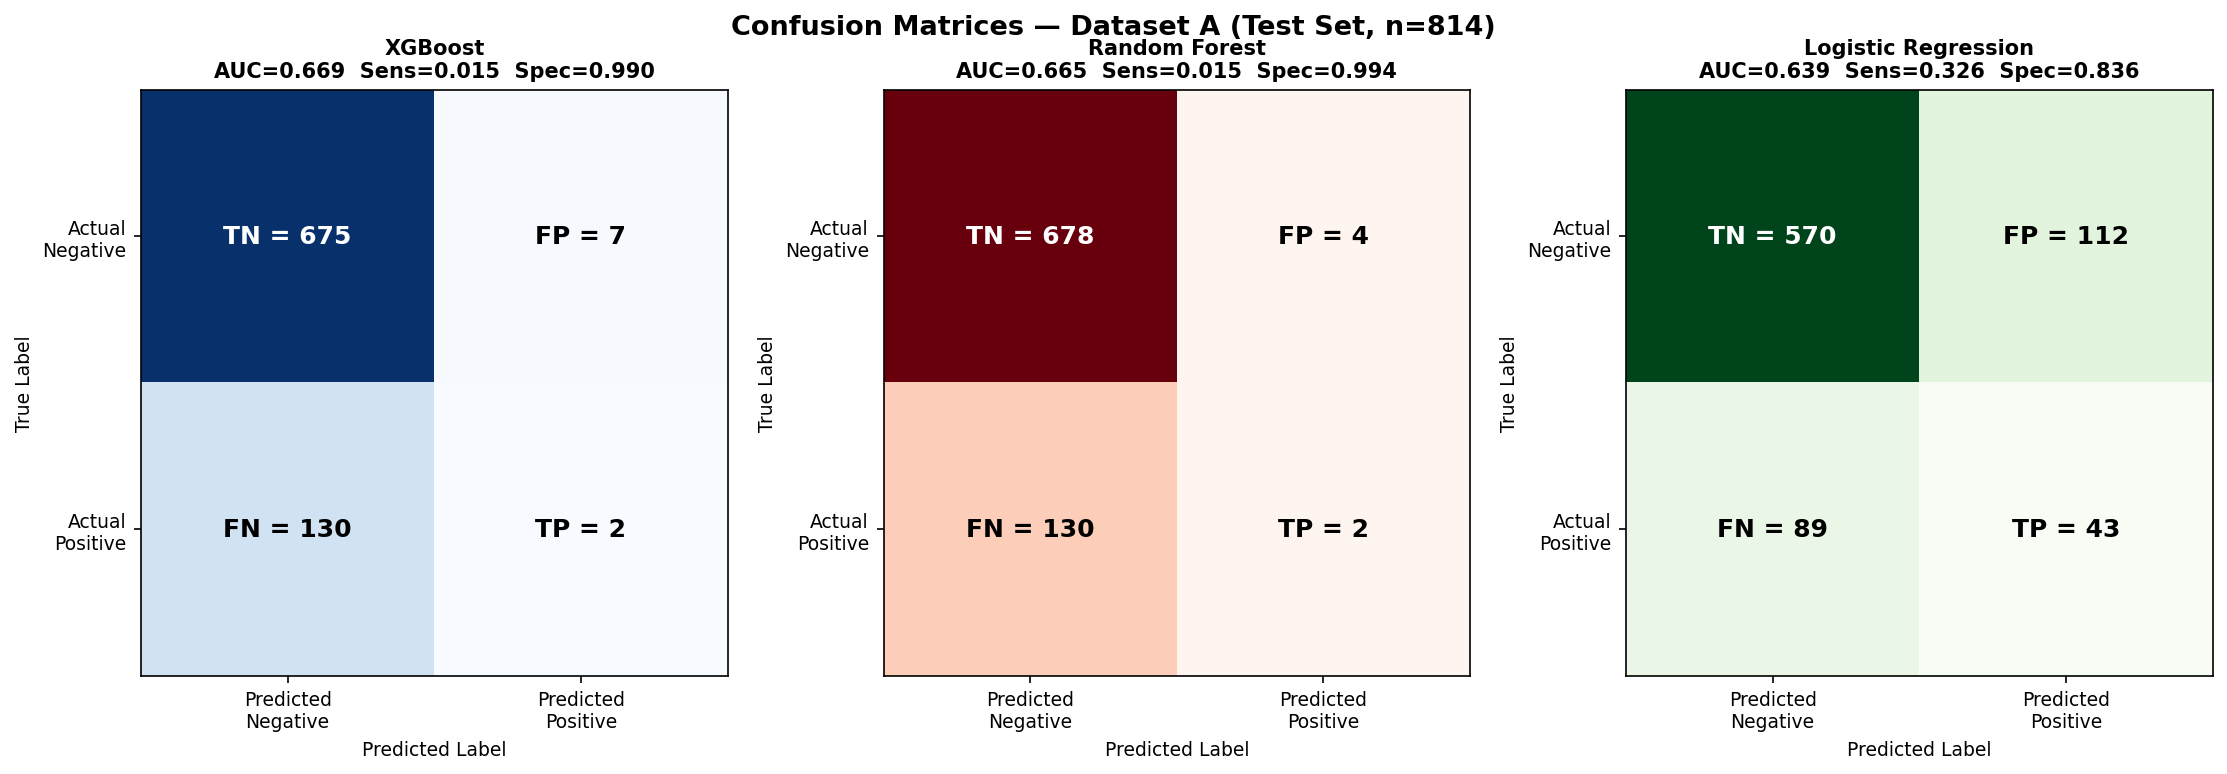

✅ Figura salvata: confusion_matrices_A.png


In [ ]:
# BLOCCO 17 — Confusion Matrix per i tre modelli (Dataset A)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

model_names  = ['XGBoost', 'RandomForest', 'LogisticRegression']
titles       = ['XGBoost', 'Random Forest', 'Logistic Regression']
colors       = ['Blues', 'Reds', 'Greens']

for ax, model_name, title, cmap in zip(axes, model_names, titles, colors):

    model  = results2['A'][model_name]['model']
    probs  = model.predict_proba(X_A_test_imp)[:, 1]
    preds  = (probs >= 0.5).astype(int)
    cm     = confusion_matrix(y_A_test, preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_val = [r['AUC-ROC'] for r in all_results2
               if r['Dataset']=='A' and r['Modello']==model_name][0]

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nNegative', 'Predicted\nPositive'],
                       fontsize=9)
    ax.set_yticklabels(['Actual\nNegative', 'Actual\nPositive'],
                       fontsize=9)

    thresh = cm.max() / 2
    labels_cm = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{labels_cm[i][j]} = {cm[i,j]}",
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm[i,j] > thresh else 'black')

    ax.set_title(f"{title}\nAUC={auc_val:.3f}  "
                 f"Sens={sensitivity:.3f}  Spec={specificity:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

fig.suptitle('Confusion Matrices — Dataset A (Test Set, n=814)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_A.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura salvata: confusion_matrices_A.png")

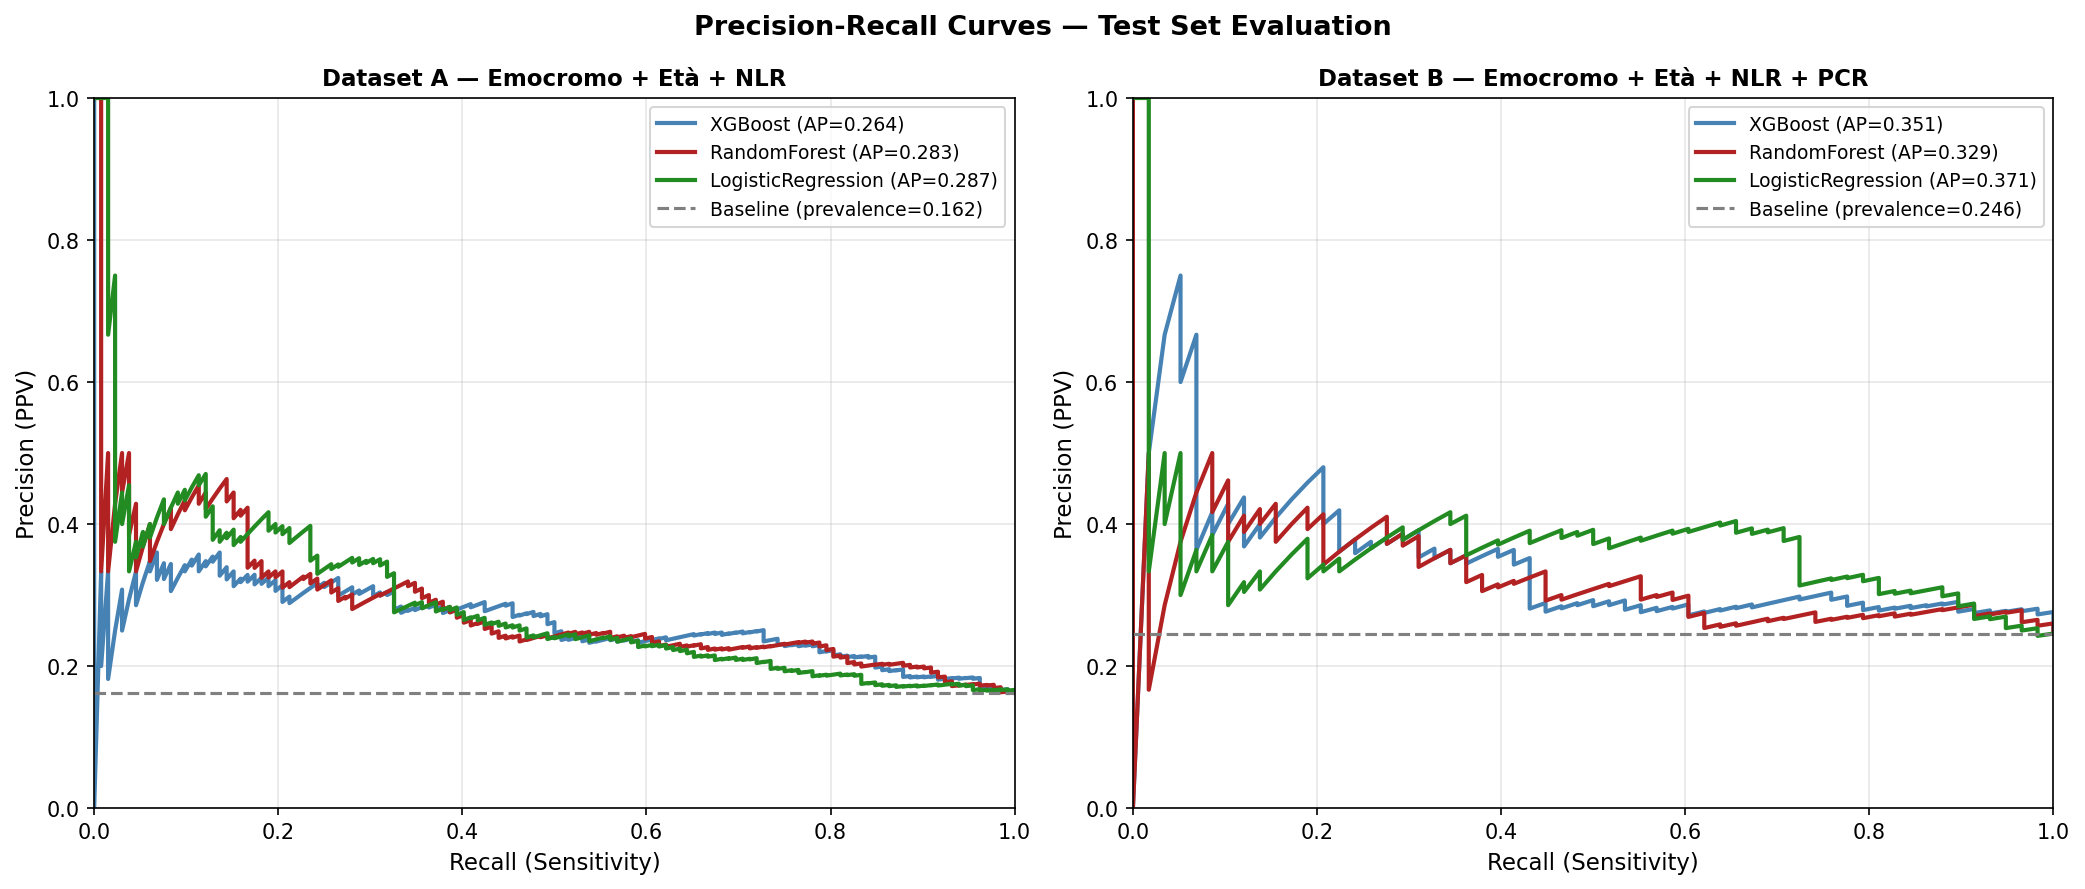

✅ Figura salvata: PR_curves_UTI.png


In [ ]:
# BLOCCO 18 — Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
colors = {'XGBoost'          : 'steelblue',
          'RandomForest'      : 'firebrick',
          'LogisticRegression': 'forestgreen'}

# Baseline = prevalenza del dataset
baseline_A = y_A_test.mean()
baseline_B = y_B_test.mean()

for ax, dataset_name, y_test, baseline, title in [
    (axes[0], 'A', y_A_test, baseline_A,
     'Dataset A — Emocromo + Età + NLR'),
    (axes[1], 'B', y_B_test, baseline_B,
     'Dataset B — Emocromo + Età + NLR + PCR')
]:
    for model_name in ['XGBoost', 'RandomForest', 'LogisticRegression']:
        model = results2[dataset_name][model_name]['model']

        if dataset_name == 'A':
            X_test = X_A_test_imp
        else:
            X_test = X_B_test_imp

        probs = model.predict_proba(X_test)[:, 1]
        ap    = average_precision_score(y_test, probs)
        prec, rec, _ = precision_recall_curve(y_test, probs)

        ax.plot(rec, prec,
                color=colors[model_name], lw=2,
                label=f"{model_name} (AP={ap:.3f})")

    # Baseline (random classifier)
    ax.axhline(y=baseline, color='gray', lw=1.5,
               linestyle='--',
               label=f'Baseline (prevalence={baseline:.3f})')

    ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
    ax.set_ylabel('Precision (PPV)', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves — Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('PR_curves_UTI.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura salvata: PR_curves_UTI.png")

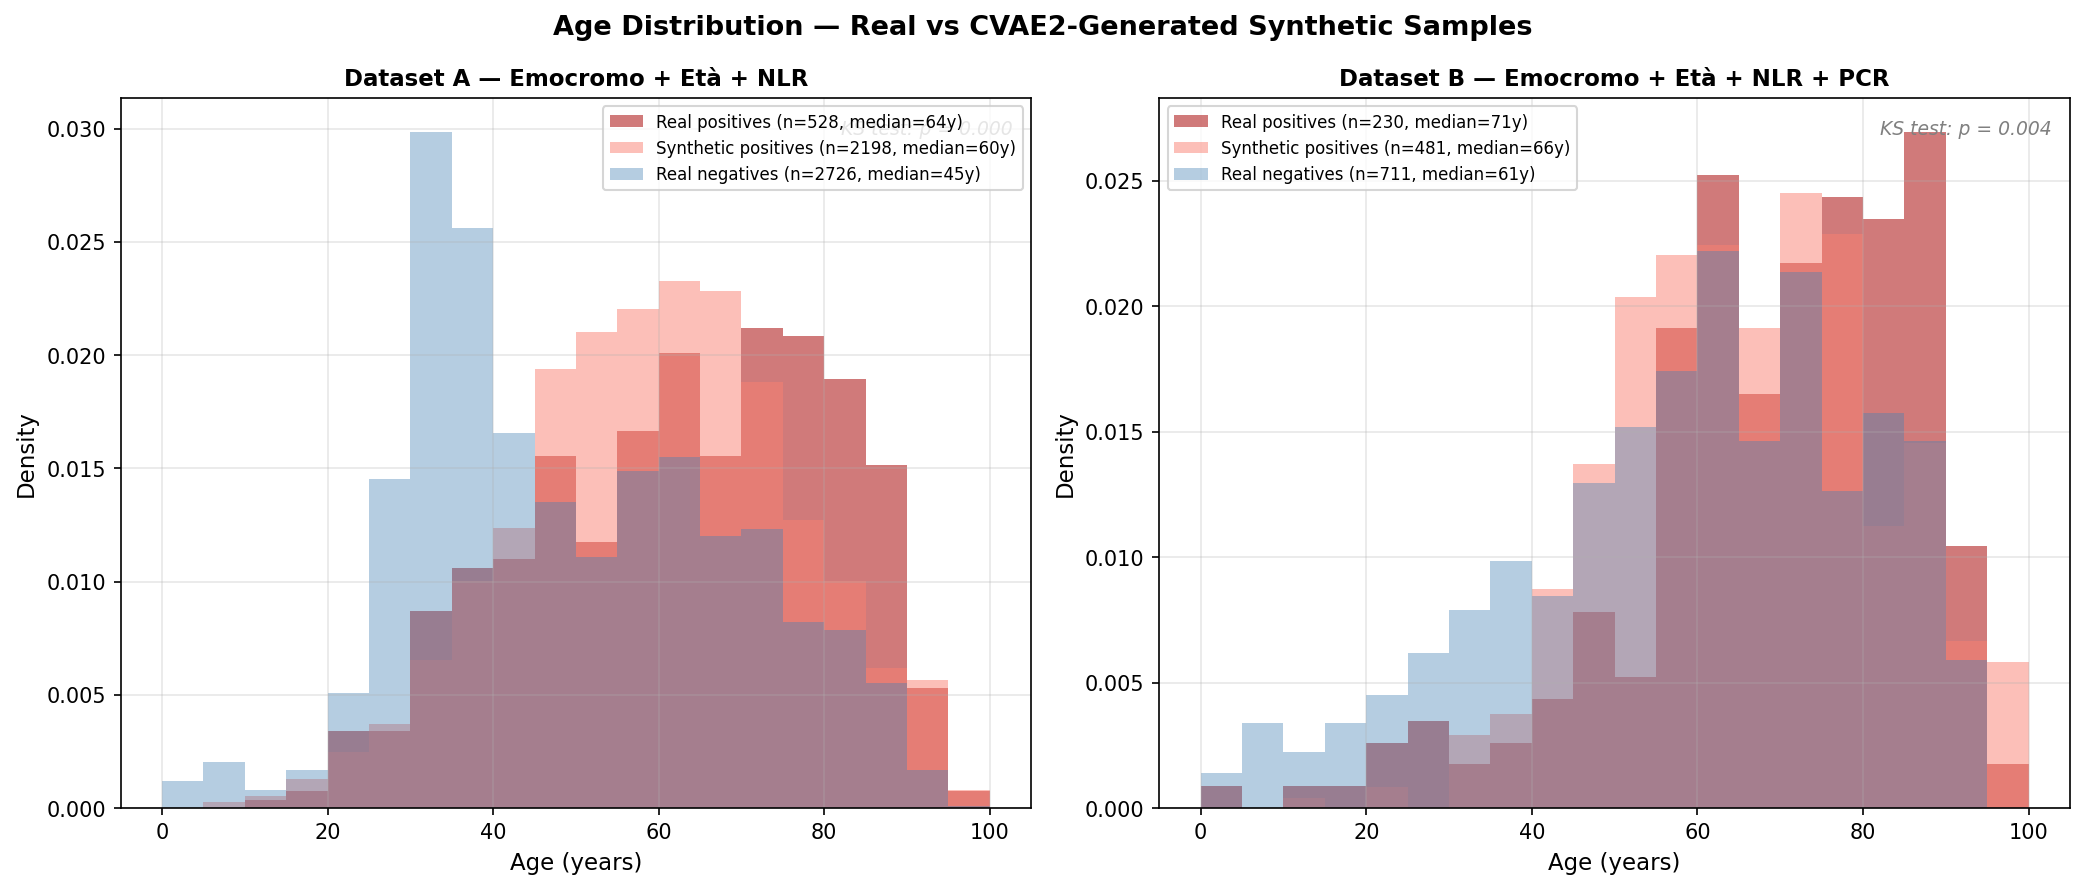

✅ Figura salvata: age_distribution_synthetic.png


In [ ]:
# BLOCCO 19 — Distribuzione età sintetici vs reali

import matplotlib.pyplot as plt
import numpy as np

idx_eta_A = features_A.index('Età')
idx_eta_B = features_B.index('Età')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

for ax, dataset_name, X_train, y_train, X_aug, y_aug, idx_eta, title in [
    (axes[0], 'A', X_A_train_imp, y_A_train,
     X_A_aug2, y_A_aug2, idx_eta_A,
     'Dataset A — Emocromo + Età + NLR'),
    (axes[1], 'B', X_B_train_imp, y_B_train,
     X_B_aug2, y_B_aug2, idx_eta_B,
     'Dataset B — Emocromo + Età + NLR + PCR')
]:
    # Età reali positivi
    eta_real_pos = X_train[y_train == 1, idx_eta]
    # Età sintetici positivi
    n_real = len(X_train)
    eta_syn_pos  = X_aug[n_real:, idx_eta]

    bins = np.arange(0, 105, 5)

    ax.hist(eta_real_pos, bins=bins, alpha=0.6,
            color='firebrick', density=True,
            label=f'Real positives (n={len(eta_real_pos)}, '
                  f'median={np.median(eta_real_pos):.0f}y)')
    ax.hist(eta_syn_pos, bins=bins, alpha=0.5,
            color='salmon', density=True,
            label=f'Synthetic positives (n={len(eta_syn_pos)}, '
                  f'median={np.median(eta_syn_pos):.0f}y)')

    # Negativi reali come riferimento
    eta_real_neg = X_train[y_train == 0, idx_eta]
    ax.hist(eta_real_neg, bins=bins, alpha=0.4,
            color='steelblue', density=True,
            label=f'Real negatives (n={len(eta_real_neg)}, '
                  f'median={np.median(eta_real_neg):.0f}y)')

    ax.set_xlabel('Age (years)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Statistiche
    from scipy.stats import ks_2samp
    ks_stat, ks_p = ks_2samp(eta_real_pos, eta_syn_pos)
    ax.text(0.98, 0.97,
            f'KS test: p = {ks_p:.3f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9, style='italic',
            color='gray')

plt.suptitle(
    'Age Distribution — Real vs CVAE2-Generated Synthetic Samples',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('age_distribution_synthetic.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura salvata: age_distribution_synthetic.png")

In [ ]:
import pickle
with open('/content/UTI_variables.pkl', 'rb') as f:
    data = pickle.load(f)

X_A_train_imp = data['X_A_train_imp']
# ... etc
print("✅ Tutte le variabili caricate correttamente")

✅ Tutte le variabili caricate correttamente


In [ ]:
# Verifica pazienti unici nel dataset finale
n_pazienti_unici = final['=Patient'].nunique()
n_osservazioni   = len(final)
n_pazienti_multi = final.groupby('=Patient').size()

print(f"Osservazioni totali:        {n_osservazioni}")
print(f"Pazienti unici:             {n_pazienti_unici}")
print(f"Pazienti con 1 visita:      {(n_pazienti_multi==1).sum()}")
print(f"Pazienti con 2+ visite:     {(n_pazienti_multi>1).sum()}")
print(f"Max visite per paziente:    {n_pazienti_multi.max()}")
print(f"Media visite per paziente:  {n_pazienti_multi.mean():.2f}")

NameError: name 'final' is not defined

In [ ]:
# BLOCCO RAPIDO — Ricostruzione dataset finale

import pandas as pd
import numpy as np

# Carica file
df = pd.read_excel('ciotti 2022+emocromo+PCR.xlsx')
df.columns = [str(c).strip() for c in df.columns]
df['First Reception Date'] = pd.to_datetime(
    df['First Reception Date'], errors='coerce')

# Target corretto
def identify_target_correct(row):
    test   = str(row['Test Description']).upper()
    coded  = str(row['Coded Result Description']).strip().upper()
    if not any(x in test for x in ['0877', '0878', 'URINOCOLT',
                                    'ES COLT', 'URINA DA CATETERE']):
        return np.nan
    if coded == 'PO':
        return 1
    if coded in ['ACB', 'ACB24', 'BNS', 'BNSC']:
        return 0
    return np.nan

df['target_correct'] = df.apply(identify_target_correct, axis=1)

target_df2 = df.dropna(subset=['target_correct']).groupby(
    ['=Patient', 'First Reception Date'])['target_correct'].max().reset_index()

# Pivot esami
esami_escludere = ['0877', '0878', 'URINOCOLT', 'ES COLT', 'URINA DA CATETERE',
    'MICROSCOPICO', 'Esterasi', 'PAR TEST', 'Workup',
    'CONTA MICROBICA', 'VITEK', 'MIC', 'Sensib', 'CONTA', 'ANTIMICRO']

df_lab = df[~df['Test Description'].str.contains(
    '|'.join(esami_escludere), case=False, na=False)].copy()
df_lab['valore'] = pd.to_numeric(
    df_lab['=[Result Value Final]'].astype(str).str.replace(',', '.'),
    errors='coerce')

pivot = df_lab.pivot_table(
    index=['=Patient', 'First Reception Date'],
    columns='Test Description',
    values='valore',
    aggfunc='first').reset_index()

if 'Interleuchina 6 - Eur' in pivot.columns:
    pivot = pivot.drop(columns=['Interleuchina 6 - Eur'])

# Età
def get_age(row):
    cf = str(row['NTS']).strip()
    if len(cf) < 11:
        return np.nan
    try:
        anno = int(cf[6:8])
        anno_nascita = 1900 + anno if anno > 26 else 2000 + anno
        anno_test = pd.to_datetime(
            row['First Reception Date'], errors='coerce').year
        eta = anno_test - anno_nascita
        return eta if 0 < eta < 120 else np.nan
    except:
        return np.nan

df_eta = df[['=Patient', 'First Reception Date', 'NTS']].drop_duplicates().copy()
df_eta['Età'] = df_eta.apply(get_age, axis=1)
eta_map = df_eta.groupby(
    ['=Patient', 'First Reception Date'])['Età'].first().reset_index()
pivot = pd.merge(pivot, eta_map,
                 on=['=Patient', 'First Reception Date'], how='left')

# NLR
if 'Neutrofili #' in pivot.columns and 'Linfociti #' in pivot.columns:
    pivot['NLR'] = pivot['Neutrofili #'] / pivot['Linfociti #']
    pivot['NLR'] = pivot['NLR'].replace([np.inf, -np.inf], np.nan)

# Merge finale
final = pd.merge(pivot, target_df2,
                 on=['=Patient', 'First Reception Date'], how='inner')

print(f"✅ Dataset ricostruito: {len(final)} osservazioni")
print(f"   Positive: {(final['target_correct']==1).sum()}")
print(f"   Negative: {(final['target_correct']==0).sum()}")

✅ Dataset ricostruito: 4068 osservazioni
   Positive: 660
   Negative: 3408


In [ ]:
# Verifica pazienti unici nel dataset finale
n_pazienti_unici = final['=Patient'].nunique()
n_osservazioni   = len(final)
n_pazienti_multi = final.groupby('=Patient').size()

print(f"Osservazioni totali:        {n_osservazioni}")
print(f"Pazienti unici:             {n_pazienti_unici}")
print(f"Pazienti con 1 visita:      {(n_pazienti_multi==1).sum()}")
print(f"Pazienti con 2+ visite:     {(n_pazienti_multi>1).sum()}")
print(f"Max visite per paziente:    {n_pazienti_multi.max()}")
print(f"Media visite per paziente:  {n_pazienti_multi.mean():.2f}")

Osservazioni totali:        4068
Pazienti unici:             2881
Pazienti con 1 visita:      2217
Pazienti con 2+ visite:     664
Max visite per paziente:    13
Media visite per paziente:  1.41


In [ ]:
# Verifica che i modelli siano disponibili
print("results2 disponibile:", 'results2' in dir())
print("y_A_test disponibile:", 'y_A_test' in dir())
print("X_A_test_imp disponibile:", 'X_A_test_imp' in dir())

results2 disponibile: False
y_A_test disponibile: False
X_A_test_imp disponibile: False


In [19]:
# Verifica che i modelli siano disponibili
print("results2 disponibile:", 'results2' in dir())
print("y_A_test disponibile:", 'y_A_test' in dir())
print("X_A_test_imp disponibile:", 'X_A_test_imp' in dir())

results2 disponibile: True
y_A_test disponibile: True
X_A_test_imp disponibile: True


AUC osservata: 0.6691
Avvio 1000 permutazioni...
  100/1000 completate...
  200/1000 completate...
  300/1000 completate...
  400/1000 completate...
  500/1000 completate...
  600/1000 completate...
  700/1000 completate...
  800/1000 completate...
  900/1000 completate...
  1000/1000 completate...

RISULTATI PERMUTATION TEST (n=1000)
AUC osservata:          0.6691
AUC media permutazioni: 0.5003
AUC mediana:            0.5009
p-value:                p < 0.001

✅ Nessuna delle 1000 permutazioni ha raggiunto
   l'AUC osservata (p < 0.001)


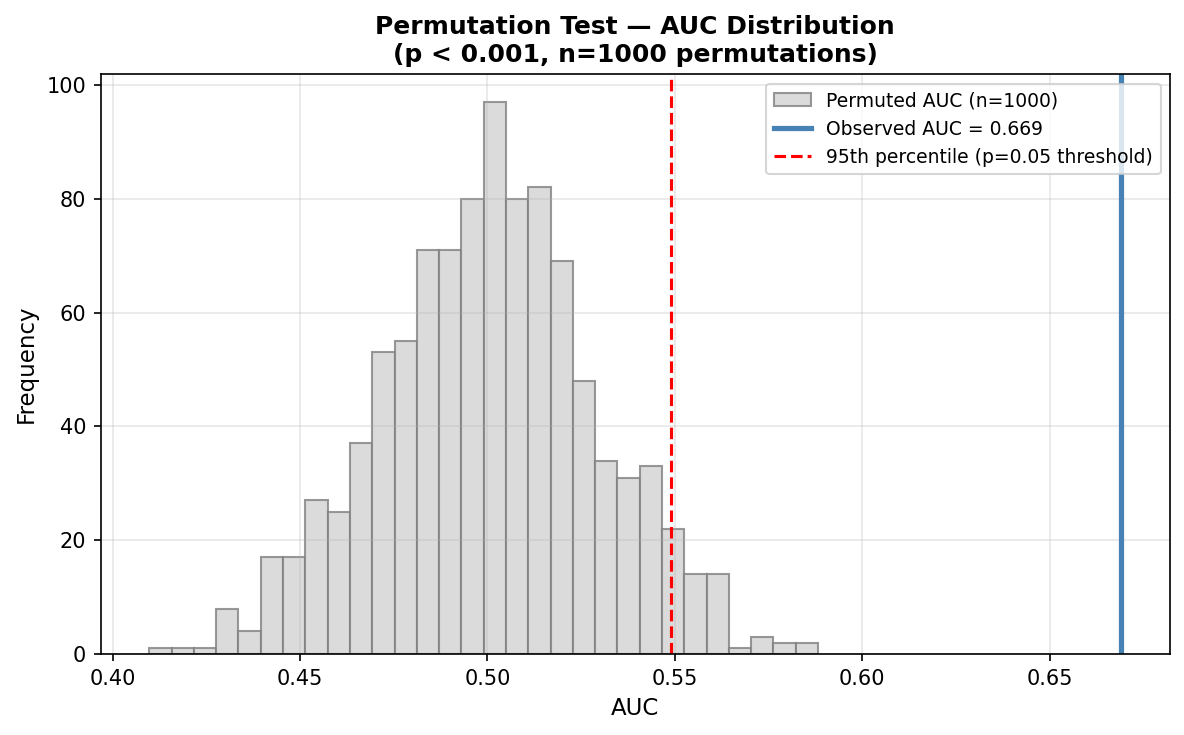

✅ Figura salvata: permutation_test_1000.png


In [20]:
# BLOCCO PERMUTATION TEST — 1000 permutazioni

from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

N_PERM = 1000
model_perm = results2['A']['XGBoost']['model']
probs_obs  = model_perm.predict_proba(X_A_test_imp)[:, 1]
auc_obs    = roc_auc_score(y_A_test, probs_obs)
auc_perm   = []

print(f"AUC osservata: {auc_obs:.4f}")
print(f"Avvio {N_PERM} permutazioni...")

for i in range(N_PERM):
    y_perm = np.random.permutation(y_A_test)
    auc_perm.append(roc_auc_score(y_perm, probs_obs))
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{N_PERM} completate...")

p_perm = np.mean(np.array(auc_perm) >= auc_obs)
p_perm_display = f"p < {1/N_PERM:.3f}" if p_perm == 0 else f"p = {p_perm:.4f}"

print(f"\n{'='*55}")
print(f"RISULTATI PERMUTATION TEST (n={N_PERM})")
print(f"{'='*55}")
print(f"AUC osservata:          {auc_obs:.4f}")
print(f"AUC media permutazioni: {np.mean(auc_perm):.4f}")
print(f"AUC mediana:            {np.median(auc_perm):.4f}")
print(f"p-value:                {p_perm_display}")

if p_perm == 0:
    print(f"\n✅ Nessuna delle {N_PERM} permutazioni ha raggiunto")
    print(f"   l'AUC osservata (p < {1/N_PERM:.3f})")
elif p_perm < 0.05:
    print(f"\n✅ AUC significativamente superiore al caso (p < 0.05)")
else:
    print(f"\n⚠️  AUC non significativamente superiore al caso")

# Grafico
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.hist(auc_perm, bins=30, color='lightgray',
        edgecolor='gray', alpha=0.8,
        label=f'Permuted AUC (n={N_PERM})')
ax.axvline(auc_obs, color='steelblue', lw=2.5,
           label=f'Observed AUC = {auc_obs:.3f}')
ax.axvline(np.percentile(auc_perm, 95), color='red',
           lw=1.5, linestyle='--',
           label=f'95th percentile (p=0.05 threshold)')
ax.set_xlabel('AUC', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(
    f'Permutation Test — AUC Distribution\n'
    f'({p_perm_display}, n={N_PERM} permutations)',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('permutation_test_1000.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura salvata: permutation_test_1000.png")